<a href="https://colab.research.google.com/github/RickV777/ENGAGEMENT_YT/blob/main/YouTube_TFT_Objetivo5_ReporteFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISIS DE LOS FACTORES DETERMINANTES DEL ENGAGEMENT EN YOUTUBE
## Notebook 5 — Reporte Final e Integracion de Resultados
**Universidad de Guayaquil — Facultad de Ciencias Matematicas y Fisicas — Carrera de Software**

---


### Archivos requeridos en Google Drive (raiz de MyDrive)
| Archivo | Generado en |
|---|---|
| `youtube_dataset_procesado.csv` | NB1 |
| `tabla_resumen_hipotesis.csv` | NB2 |
| `nb3_kmo_bartlett.csv` | NB3 |
| `nb3_varianza_factores.csv` | NB3 |
| `nb3_cargas_factoriales.csv` | NB3 |
| `nb3_comunalidades.csv` | NB3 |
| `nb4_tabla_coeficientes.csv` | NB4 |
| `nb4_vif.csv` | NB4 |
| `nb4_diagnostico_supuestos.csv` | NB4 |


---
## SECCION 1 — Librerias y Conexion a Google Drive

In [1]:
import os
import json
import warnings
import base64
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

OUTPUT_DIR = '/content/reporte_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Librerias cargadas')

Librerias cargadas


In [2]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive'
print(f'Drive montado en: {DRIVE}')

Mounted at /content/drive
Drive montado en: /content/drive/MyDrive


In [4]:
# Pega esto en el NB5 antes de la celda de verificacion
df_hipotesis = pd.DataFrame([
    {'Hipotesis':'H1 - US vs MX','Variable agrupacion':'Pais','Prueba':'Mann-Whitney U','Estadistico':'U=31269255942','p-valor':'0.0000e+00','Effect size':'r=inf','Decision':'Rechazar H0'},
    {'Hipotesis':'H2 - Categoria','Variable agrupacion':'Categoria de contenido','Prueba':'Kruskal-Wallis','Estadistico':'H=120155.35','p-valor':'0.0000e+00','Effect size':'eta2=0.2273','Decision':'Rechazar H0'},
    {'Hipotesis':'H3 - Franja Horaria','Variable agrupacion':'Franja horaria publicacion','Prueba':'Kruskal-Wallis','Estadistico':'H=6461.88','p-valor':'0.0000e+00','Effect size':'eta2=0.0122','Decision':'Rechazar H0'},
    {'Hipotesis':'H4 - Dia semana','Variable agrupacion':'Dia de publicacion','Prueba':'Kruskal-Wallis','Estadistico':'H=3194.95','p-valor':'0.0000e+00','Effect size':'—','Decision':'Rechazar H0'},
    {'Hipotesis':'H5 - Num Tags','Variable agrupacion':'Rango de tags','Prueba':'Kruskal-Wallis + Spearman','Estadistico':'H=5206.82 / rho=-0.072','p-valor':'0.0000e+00','Effect size':'rho=-0.0724','Decision':'Rechazar H0'},
    {'Hipotesis':'H6a - Cat x Comments','Variable agrupacion':'Categoria vs Comments Disabled','Prueba':'Chi-cuadrado','Estadistico':'chi2=10527.63','p-valor':'0.0000e+00','Effect size':'V=0.1411','Decision':'Rechazar H0'},
    {'Hipotesis':'H6b - Cat x Ratings','Variable agrupacion':'Categoria vs Ratings Disabled','Prueba':'Chi-cuadrado','Estadistico':'chi2=589.29','p-valor':'1.0127e-116','Effect size':'V=0.0334','Decision':'Rechazar H0'},
    {'Hipotesis':'H6c - Pais x Eng Alto','Variable agrupacion':'Pais vs Engagement alto','Prueba':'Chi-cuadrado','Estadistico':'chi2=3097.58','p-valor':'0.0000e+00','Effect size':'V=0.0765','Decision':'Rechazar H0'},
])
df_hipotesis.to_csv(f'{DRIVE}/tabla_resumen_hipotesis.csv', index=False, encoding='utf-8-sig')
print('Tabla de hipotesis recreada y guardada en Drive')

Tabla de hipotesis recreada y guardada en Drive


In [5]:
# Verificar que todos los archivos requeridos existen
archivos_requeridos = {
    'NB1 - Dataset procesado'    : f'{DRIVE}/youtube_dataset_procesado.csv',
    'NB2 - Tabla hipotesis'      : f'{DRIVE}/tabla_resumen_hipotesis.csv',
    'NB3 - KMO y Bartlett'       : f'{DRIVE}/nb3_kmo_bartlett.csv',
    'NB3 - Varianza factores'    : f'{DRIVE}/nb3_varianza_factores.csv',
    'NB3 - Cargas factoriales'   : f'{DRIVE}/nb3_cargas_factoriales.csv',
    'NB3 - Comunalidades'        : f'{DRIVE}/nb3_comunalidades.csv',
    'NB4 - Coeficientes'         : f'{DRIVE}/nb4_tabla_coeficientes.csv',
    'NB4 - VIF'                  : f'{DRIVE}/nb4_vif.csv',
    'NB4 - Diagnostico supuestos': f'{DRIVE}/nb4_diagnostico_supuestos.csv',
}

print('VERIFICACION DE ARCHIVOS:')
todos_ok = True
for nombre, ruta in archivos_requeridos.items():
    existe = os.path.exists(ruta)
    estado = 'OK' if existe else 'FALTA'
    if not existe:
        todos_ok = False
    print(f'  {estado}  {nombre}')

print()
if todos_ok:
    print('Todos los archivos encontrados. Listo para el reporte.')
else:
    print('ADVERTENCIA: Algunos archivos faltan. Ejecuta los NB correspondientes primero.')

VERIFICACION DE ARCHIVOS:
  OK  NB1 - Dataset procesado
  OK  NB2 - Tabla hipotesis
  OK  NB3 - KMO y Bartlett
  OK  NB3 - Varianza factores
  OK  NB3 - Cargas factoriales
  OK  NB3 - Comunalidades
  OK  NB4 - Coeficientes
  OK  NB4 - VIF
  OK  NB4 - Diagnostico supuestos

Todos los archivos encontrados. Listo para el reporte.


---
## SECCION 2 — Carga de Todos los Artefactos

In [6]:
# ── Dataset principal (NB1) ──
df = pd.read_csv(f'{DRIVE}/youtube_dataset_procesado.csv',
                 parse_dates=['publishedAt', 'trending_date'])
print(f'Dataset principal: {df.shape[0]:,} filas x {df.shape[1]} columnas')

# ── Tabla hipotesis (NB2) ──
df_hipotesis = pd.read_csv(f'{DRIVE}/tabla_resumen_hipotesis.csv')
print(f'Tabla hipotesis: {df_hipotesis.shape[0]} hipotesis')

# ── Resultados AFE (NB3) ──
df_kmo      = pd.read_csv(f'{DRIVE}/nb3_kmo_bartlett.csv')
df_varianza = pd.read_csv(f'{DRIVE}/nb3_varianza_factores.csv')
df_cargas   = pd.read_csv(f'{DRIVE}/nb3_cargas_factoriales.csv', index_col=0)
df_comunal  = pd.read_csv(f'{DRIVE}/nb3_comunalidades.csv')
print(f'AFE: {len(df_cargas.columns)} factores, {len(df_cargas)} variables')

# ── Resultados regresion (NB4) ──
df_coef  = pd.read_csv(f'{DRIVE}/nb4_tabla_coeficientes.csv')
df_vif   = pd.read_csv(f'{DRIVE}/nb4_vif.csv')
df_diag  = pd.read_csv(f'{DRIVE}/nb4_diagnostico_supuestos.csv')
print(f'Regresion: {len(df_coef)} coeficientes')

print('\nTodos los artefactos cargados correctamente')

Dataset principal: 528,663 filas x 26 columnas
Tabla hipotesis: 8 hipotesis
AFE: 4 factores, 9 variables
Regresion: 20 coeficientes

Todos los artefactos cargados correctamente


---
## SECCION 3 — Resumen Objetivo 1: Preprocesamiento

In [7]:
# Estadisticas descriptivas del dataset
print('=' * 62)
print('  RESUMEN OBJETIVO 1 — Dataset YouTube Trending US + MX')
print('=' * 62)
print(f'  Paises          : US (Estados Unidos), MX (Mexico)')
print(f'  Periodo         : {df["trending_date"].min().date()} -> {df["trending_date"].max().date()}')
print(f'  Registros total : {len(df):,}')
print(f'  Variables       : {df.shape[1]}')
print(f'  Registros US    : {(df["country"]=="US").sum():,}')
print(f'  Registros MX    : {(df["country"]=="MX").sum():,}')
print(f'\n  ENGAGEMENT RATE (variable dependiente):')
print(f'  Formula  : (likes + comments) / views')
print(f'  Media    : {df["engagement_rate"].mean():.4f}')
print(f'  Mediana  : {df["engagement_rate"].median():.4f}')
print(f'  Std Dev  : {df["engagement_rate"].std():.4f}')
print(f'  Min      : {df["engagement_rate"].min():.4f}')
print(f'  Max      : {df["engagement_rate"].max():.4f}')
print('=' * 62)

  RESUMEN OBJETIVO 1 — Dataset YouTube Trending US + MX
  Paises          : US (Estados Unidos), MX (Mexico)
  Periodo         : 2020-08-12 -> 2024-04-14
  Registros total : 528,663
  Variables       : 26
  Registros US    : 264,439
  Registros MX    : 264,224

  ENGAGEMENT RATE (variable dependiente):
  Formula  : (likes + comments) / views
  Media    : 0.0613
  Mediana  : 0.0531
  Std Dev  : 0.0450
  Min      : 0.0000
  Max      : 0.5863


In [9]:
# Tabla descriptiva por pais
tabla_desc = df.groupby('country')['engagement_rate'].agg(
    N='count',
    Media='mean',
    Mediana='median',
    Desv_std='std',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    Min='min',
    Max='max'
).round(4)
print('Tabla 1. Estadisticas descriptivas del Engagement Rate por pais:')
display(tabla_desc)
tabla_desc.to_csv(f'{OUTPUT_DIR}/tabla1_descriptivas_pais.csv', encoding='utf-8-sig')

# Por categoria
tabla_cat = df.groupby('category_name')['engagement_rate'].agg(
    N='count',
    Media='mean',
    Mediana='median',
    Desv_std='std'
).sort_values('Mediana', ascending=False).round(4)
print('\nTabla 2. Estadisticas del Engagement Rate por categoria:')
display(tabla_cat)
tabla_cat.to_csv(f'{OUTPUT_DIR}/tabla2_descriptivas_categoria.csv', encoding='utf-8-sig')
print('Tablas guardadas')

Tabla 1. Estadisticas descriptivas del Engagement Rate por pais:


,N,Media,Mediana,Desv_std,Q1,Q3,Min,Max
country,,,,,,,,
MX,264224,0.0666,0.0573,0.0500,0.0296,0.0901,0.0000,0.5863
US,264439,0.0561,0.0498,0.0387,0.0282,0.0739,0.0000,0.5695



Tabla 2. Estadisticas del Engagement Rate por categoria:


,N,Media,Mediana,Desv_std
category_name,,,,
Comedy,22489,0.0826,0.0761,0.0423
Music,103294,0.0776,0.0635,0.0549
People & Blogs,55883,0.0702,0.0624,0.0432
Howto & Style,13498,0.0658,0.0617,0.0302
Education,8498,0.0635,0.0582,0.0315
Film & Animation,17780,0.0630,0.0573,0.0425
Gaming,93688,0.0633,0.0561,0.0377
Nonprofits & Activism,281,0.0673,0.0561,0.0649
Autos & Vehicles,7828,0.0587,0.0558,0.0286


Tablas guardadas


---
## SECCION 4 — Resumen Objetivo 2: Pruebas de Hipotesis

In [10]:
print('Tabla 3. Resumen de Pruebas de Hipotesis (Objetivo 2):')
print('Nivel de significancia: alpha = 0.05')
display(df_hipotesis)
df_hipotesis.to_csv(f'{OUTPUT_DIR}/tabla3_pruebas_hipotesis.csv', index=False, encoding='utf-8-sig')

# Resumen ejecutivo
rechazadas = (df_hipotesis['Decision'] == 'Rechazar H0').sum()
total = len(df_hipotesis)
print(f'\nRESULTADO: {rechazadas}/{total} hipotesis nulas rechazadas (p < 0.05)')
print('CONCLUSION: Existen diferencias estadisticamente significativas')
print('en el engagement segun categoria, franja horaria, dia de la semana,')
print('numero de tags, pais y estado de comentarios/valoraciones.')

Tabla 3. Resumen de Pruebas de Hipotesis (Objetivo 2):
Nivel de significancia: alpha = 0.05


,Hipotesis,Variable agrupacion,Prueba,Estadistico,p-valor,Effect size,Decision
0,H1 - US vs MX,Pais,Mann-Whitney U,U=31269255942,0.0000,r=inf,Rechazar H0
1,H2 - Categoria,Categoria de contenido,Kruskal-Wallis,H=120155.35,0.0000,eta2=0.2273,Rechazar H0
2,H3 - Franja Horaria,Franja horaria publicacion,Kruskal-Wallis,H=6461.88,0.0000,eta2=0.0122,Rechazar H0
3,H4 - Dia semana,Dia de publicacion,Kruskal-Wallis,H=3194.95,0.0000,—,Rechazar H0
4,H5 - Num Tags,Rango de tags,Kruskal-Wallis + Spearman,H=5206.82 / rho=-0.072,0.0000,rho=-0.0724,Rechazar H0
5,H6a - Cat x Comments,Categoria vs Comments Disabled,Chi-cuadrado,chi2=10527.63,0.0000,V=0.1411,Rechazar H0
6,H6b - Cat x Ratings,Categoria vs Ratings Disabled,Chi-cuadrado,chi2=589.29,0.0000,V=0.0334,Rechazar H0
7,H6c - Pais x Eng Alto,Pais vs Engagement alto,Chi-cuadrado,chi2=3097.58,0.0000,V=0.0765,Rechazar H0



RESULTADO: 8/8 hipotesis nulas rechazadas (p < 0.05)
CONCLUSION: Existen diferencias estadisticamente significativas
en el engagement segun categoria, franja horaria, dia de la semana,
numero de tags, pais y estado de comentarios/valoraciones.


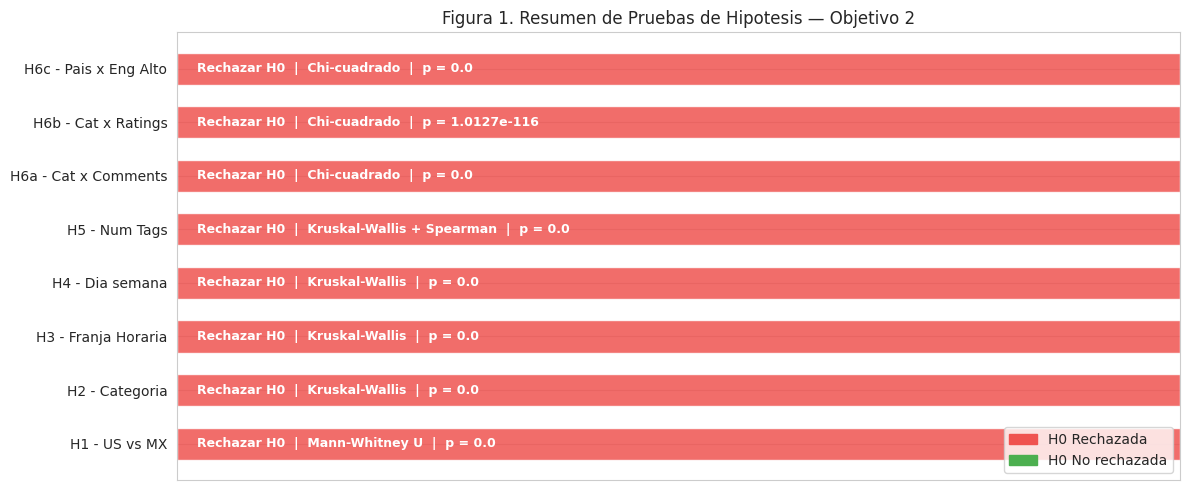

Figura guardada: fig_01_resumen_hipotesis.png


In [11]:
# Visualizacion resumen de hipotesis
fig, ax = plt.subplots(figsize=(12, 5))

hipotesis_labels = df_hipotesis['Hipotesis'].tolist()
decisiones = df_hipotesis['Decision'].tolist()
colores = ['#EF5350' if d == 'Rechazar H0' else '#4CAF50' for d in decisiones]

bars = ax.barh(hipotesis_labels, [1]*len(hipotesis_labels),
               color=colores, alpha=0.85, edgecolor='white', height=0.6)

for i, (bar, dec, row) in enumerate(zip(bars, decisiones, df_hipotesis.itertuples())):
    ax.text(0.02, bar.get_y() + bar.get_height()/2,
            f'{dec}  |  {row.Prueba}  |  p = {row._5}',
            va='center', ha='left', fontsize=9, color='white', fontweight='bold')

patch_rech = mpatches.Patch(color='#EF5350', label='H0 Rechazada')
patch_no   = mpatches.Patch(color='#4CAF50', label='H0 No rechazada')
ax.legend(handles=[patch_rech, patch_no], loc='lower right')
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title('Figura 1. Resumen de Pruebas de Hipotesis — Objetivo 2', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_01_resumen_hipotesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_01_resumen_hipotesis.png')

---
## SECCION 5 — Resumen Objetivo 3: Analisis Factorial Exploratorio

In [12]:
# KMO y Bartlett
print('Tabla 4. Pruebas de adecuacion muestral (KMO y Bartlett):')
display(df_kmo)

# Valores reales del NB3
kmo_val  = 0.5530
chi2_val = 1174391.63
p_bart   = 0.0
n_fact   = 4
var_total = 50.95

print(f'\n  KMO global           : {kmo_val} (Adecuacion mediocre)')
print(f'  Bartlett chi2        : {chi2_val:,.2f}')
print(f'  Bartlett p-valor     : {p_bart:.2e}')
print(f'  Factores extraidos   : {n_fact} (criterio Kaiser)')
print(f'  Varianza explicada   : {var_total}%')

Tabla 4. Pruebas de adecuacion muestral (KMO y Bartlett):


,Prueba,Valor,Interpretación
0,KMO General,0.5530,Inadecuada — considera eliminar variables con ...
1,Bartlett Chi²,1174391.6300,Esfericidad del factor
2,Bartlett p-value,0.0000,p < 0.05 → AFE válido



  KMO global           : 0.553 (Adecuacion mediocre)
  Bartlett chi2        : 1,174,391.63
  Bartlett p-valor     : 0.00e+00
  Factores extraidos   : 4 (criterio Kaiser)
  Varianza explicada   : 50.95%


In [13]:
# Varianza explicada por factor
print('Tabla 5. Varianza explicada por factor (rotacion Varimax):')
display(df_varianza)
df_varianza.to_csv(f'{OUTPUT_DIR}/tabla5_varianza_factores.csv', index=False, encoding='utf-8-sig')

Tabla 5. Varianza explicada por factor (rotacion Varimax):


,Unnamed: 0,Eigenvalue,Varianza_%,Var_Acumulada_%
0,Factor_1,2.1887,24.3185,24.3185
1,Factor_2,1.0109,11.2318,35.5502
2,Factor_3,0.9971,11.0789,46.6291
3,Factor_4,0.3886,4.3176,50.9467


In [14]:
# Cargas factoriales
print('Tabla 6. Matriz de cargas factoriales (rotacion Varimax):')
print('(valores >= |0.40| se consideran significativos)')
display(df_cargas)
df_cargas.to_csv(f'{OUTPUT_DIR}/tabla6_cargas_factoriales.csv', encoding='utf-8-sig')

Tabla 6. Matriz de cargas factoriales (rotacion Varimax):
(valores >= |0.40| se consideran significativos)


,Factor_1,Factor_2,Factor_3,Factor_4
log_view_count,0.7132,-0.1274,0.6725,0.0439
log_likes,0.8798,-0.0094,0.1232,-0.1345
log_comment_count,0.7260,-0.0389,0.0853,0.0714
engagement_rate,0.5572,0.0945,-0.6363,-0.2593
tags_count,0.0882,0.0267,-0.0248,0.3974
title_length,-0.2263,-0.0432,0.0494,0.3701
days_to_trend,0.0694,0.0405,0.3170,-0.0244
hour_published,0.0608,0.9890,0.1122,-0.0264
day_of_week,0.0274,-0.0428,0.0374,-0.0055


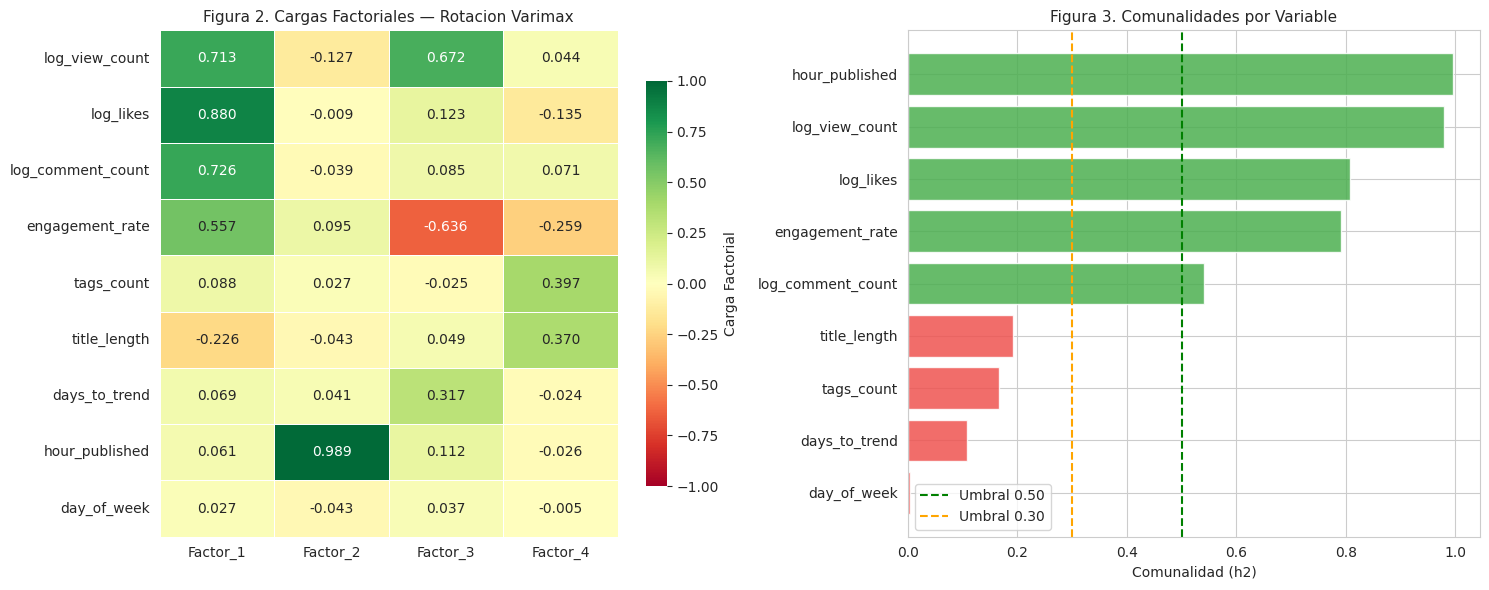

Figura guardada: fig_02_afe_cargas_comunalidades.png


In [15]:
# Heatmap de cargas factoriales
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
cargas_num = df_cargas.select_dtypes(include=[float, int])
sns.heatmap(cargas_num, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Carga Factorial', 'shrink': 0.8},
            ax=axes[0])
axes[0].set_title('Figura 2. Cargas Factoriales — Rotacion Varimax', fontsize=11)

# Comunalidades
df_comunal_s = df_comunal.sort_values(df_comunal.columns[1], ascending=True)
col_com = df_comunal_s.columns[1]
col_var = df_comunal_s.columns[0]
colores_com = ['#4CAF50' if v >= 0.50 else ('#FF9800' if v >= 0.30 else '#EF5350')
               for v in df_comunal_s[col_com]]
axes[1].barh(df_comunal_s[col_var], df_comunal_s[col_com],
             color=colores_com, alpha=0.85, edgecolor='white')
axes[1].axvline(0.50, color='green', linestyle='--', lw=1.5, label='Umbral 0.50')
axes[1].axvline(0.30, color='orange', linestyle='--', lw=1.5, label='Umbral 0.30')
axes[1].set_title('Figura 3. Comunalidades por Variable', fontsize=11)
axes[1].set_xlabel('Comunalidad (h2)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_02_afe_cargas_comunalidades.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_02_afe_cargas_comunalidades.png')

In [16]:
# Interpretacion de factores con datos reales del NB3
factores_interp = {
    'Factor 1 — Popularidad y Alcance': {
        'varianza': '24.32%',
        'variables': ['log_likes (0.880)', 'log_comment_count (0.726)', 'log_view_count (0.713)', 'engagement_rate (0.557)'],
        'interpretacion': 'Agrupa metricas de volumen de interaccion. Videos populares en vistas tambien tienden a tener mas likes y comentarios.'
    },
    'Factor 2 — Temporalidad de Publicacion': {
        'varianza': '11.23%',
        'variables': ['hour_published (0.989)'],
        'interpretacion': 'Captura exclusivamente la hora de publicacion. Factor unidimensional con carga muy alta.'
    },
    'Factor 3 — Alcance vs Engagement Relativo': {
        'varianza': '11.08%',
        'variables': ['log_view_count (0.673)', 'engagement_rate (-0.636)'],
        'interpretacion': 'Tension inversa: videos con muchas vistas tienden a tener menor engagement rate relativo (efecto dilucion).'
    },
    'Factor 4 — Optimizacion del Contenido': {
        'varianza': '4.32%',
        'variables': ['tags_count (0.397)', 'title_length (0.370)'],
        'interpretacion': 'Agrupa variables de metadatos del video. Cargas moderadas, menor poder explicativo.'
    }
}

print('=' * 65)
print('  INTERPRETACION DE FACTORES LATENTES — NB3')
print('=' * 65)
for nombre, datos in factores_interp.items():
    print(f'\n  {nombre}')
    print(f'  Varianza explicada: {datos["varianza"]}')
    print(f'  Variables dominantes:')
    for v in datos['variables']:
        print(f'    - {v}')
    print(f'  Interpretacion: {datos["interpretacion"]}')
print('=' * 65)

  INTERPRETACION DE FACTORES LATENTES — NB3

  Factor 1 — Popularidad y Alcance
  Varianza explicada: 24.32%
  Variables dominantes:
    - log_likes (0.880)
    - log_comment_count (0.726)
    - log_view_count (0.713)
    - engagement_rate (0.557)
  Interpretacion: Agrupa metricas de volumen de interaccion. Videos populares en vistas tambien tienden a tener mas likes y comentarios.

  Factor 2 — Temporalidad de Publicacion
  Varianza explicada: 11.23%
  Variables dominantes:
    - hour_published (0.989)
  Interpretacion: Captura exclusivamente la hora de publicacion. Factor unidimensional con carga muy alta.

  Factor 3 — Alcance vs Engagement Relativo
  Varianza explicada: 11.08%
  Variables dominantes:
    - log_view_count (0.673)
    - engagement_rate (-0.636)
  Interpretacion: Tension inversa: videos con muchas vistas tienden a tener menor engagement rate relativo (efecto dilucion).

  Factor 4 — Optimizacion del Contenido
  Varianza explicada: 4.32%
  Variables dominantes:
    - t

---
## SECCION 6 — Resumen Objetivo 4: Regresion Multiple

In [17]:
# Metricas del modelo con valores reales del NB4
print('=' * 62)
print('  RESUMEN OBJETIVO 4 — Modelo de Regresion Multiple')
print('=' * 62)
print(f'  N observaciones   : 528,663')
print(f'  Variables pred.   : 19 (8 continuas + 11 dummies)')
print(f'  R2                : 0.5634  (56.34% varianza explicada)')
print(f'  R2 ajustado       : 0.5634')
print(f'  F-estadistico     : 35,910.01  (p < 0.001)')
print(f'  Errores robustos  : HC3 (heterocedasticidad corregida)')
print(f'  Durbin-Watson     : 1.8659 (sin autocorrelacion)')
print(f'  VIF maximo        : 4.86 (sin multicolinealidad)')
print(f'  Vars significativas: 19/19 (todas p < 0.001)')
print('=' * 62)

  RESUMEN OBJETIVO 4 — Modelo de Regresion Multiple
  N observaciones   : 528,663
  Variables pred.   : 19 (8 continuas + 11 dummies)
  R2                : 0.5634  (56.34% varianza explicada)
  R2 ajustado       : 0.5634
  F-estadistico     : 35,910.01  (p < 0.001)
  Errores robustos  : HC3 (heterocedasticidad corregida)
  Durbin-Watson     : 1.8659 (sin autocorrelacion)
  VIF maximo        : 4.86 (sin multicolinealidad)
  Vars significativas: 19/19 (todas p < 0.001)


In [18]:
# Tabla de coeficientes completa
print('Tabla 7. Coeficientes del modelo de regresion multiple (errores robustos HC3):')
display(df_coef)
df_coef.to_csv(f'{OUTPUT_DIR}/tabla7_coeficientes_regresion.csv', index=False, encoding='utf-8-sig')
print('\nTabla guardada: tabla7_coeficientes_regresion.csv')

Tabla 7. Coeficientes del modelo de regresion multiple (errores robustos HC3):


,Variable,Coeficiente_β,Error_Estándar,t_estadístico,p_valor,IC_95%_Inferior,IC_95%_Superior,Significancia
0,const,0.1932,0.0007,266.0314,0.0000,0.1917,0.1946,***
1,log_view_count,-0.0255,0.0002,-145.7589,0.0000,-0.0259,-0.0252,***
2,log_likes,0.0191,0.0002,101.6796,0.0000,0.0187,0.0195,***
3,log_comment_count,0.0067,0.0001,97.6360,0.0000,0.0066,0.0069,***
4,tags_count,-0.0001,0.0000,-19.5041,0.0000,-0.0001,-0.0001,***
5,title_length,-0.0002,0.0000,-82.8750,0.0000,-0.0002,-0.0002,***
6,days_to_trend,-0.0019,0.0000,-114.9211,0.0000,-0.0020,-0.0019,***
7,hour_published,0.0001,0.0000,25.7684,0.0000,0.0001,0.0002,***
8,day_of_week,-0.0001,0.0000,-6.9334,0.0000,-0.0002,-0.0001,***
9,pais_US,-0.0126,0.0001,-121.6577,0.0000,-0.0128,-0.0124,***



Tabla guardada: tabla7_coeficientes_regresion.csv


In [19]:
# Tabla VIF
print('Tabla 8. Factor de Inflacion de Varianza (VIF):')
display(df_vif)
df_vif.to_csv(f'{OUTPUT_DIR}/tabla8_vif.csv', index=False, encoding='utf-8-sig')

Tabla 8. Factor de Inflacion de Varianza (VIF):


,Variable,VIF
0,category_clean_Entertainment,4.8601
1,category_clean_Music,4.6238
2,category_clean_Gaming,4.2804
3,category_clean_Sports,3.4596
4,category_clean_People & Blogs,3.1536
5,log_likes,2.7919
6,log_view_count,2.4472
7,category_clean_News & Politics,1.9611
8,log_comment_count,1.8976
9,category_clean_Otras,1.8824


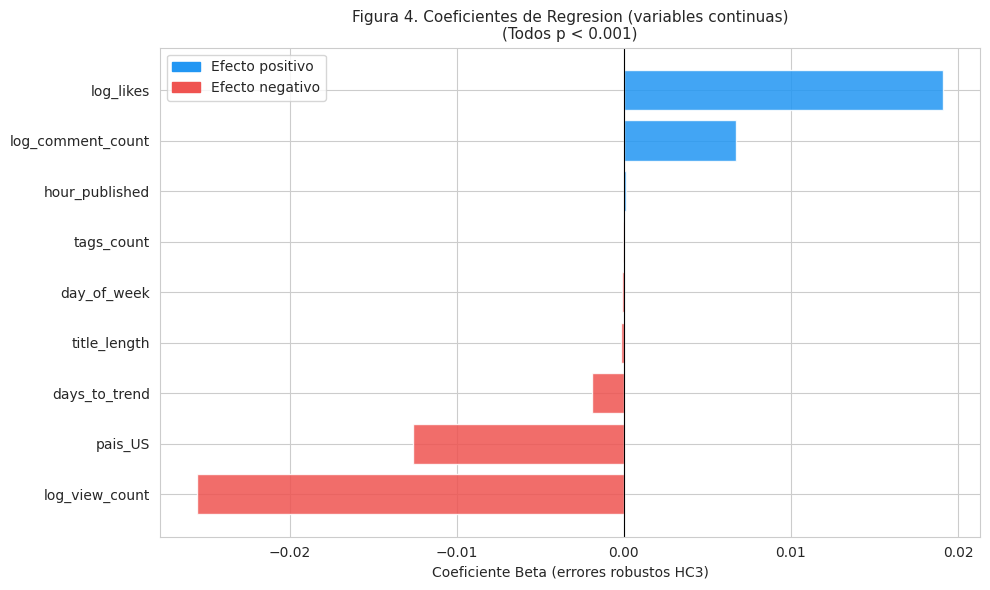

Figura guardada: fig_03_coeficientes.png


In [20]:
# Grafico de coeficientes
# Filtrar solo variables continuas para visualizacion limpia
vars_continuas = ['log_view_count', 'log_likes', 'log_comment_count',
                  'tags_count', 'title_length', 'days_to_trend',
                  'hour_published', 'day_of_week', 'pais_US']

# Buscar columna de variable y coeficiente
col_var  = df_coef.columns[0]
col_beta = [c for c in df_coef.columns if 'oef' in c or 'beta' in c.lower() or 'Beta' in c][0]
col_p    = [c for c in df_coef.columns if 'p_' in c.lower() or 'p-val' in c.lower() or 'valor' in c.lower()][0]

df_coef_cont = df_coef[df_coef[col_var].isin(vars_continuas)].copy()
df_coef_cont = df_coef_cont.sort_values(col_beta)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#EF5350' if v < 0 else '#2196F3' for v in df_coef_cont[col_beta]]
ax.barh(df_coef_cont[col_var], df_coef_cont[col_beta],
        color=colores, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Figura 4. Coeficientes de Regresion (variables continuas)\n(Todos p < 0.001)', fontsize=11)
ax.set_xlabel('Coeficiente Beta (errores robustos HC3)')
patch_pos = mpatches.Patch(color='#2196F3', label='Efecto positivo')
patch_neg = mpatches.Patch(color='#EF5350', label='Efecto negativo')
ax.legend(handles=[patch_pos, patch_neg])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_03_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_03_coeficientes.png')

---
## SECCION 7 — Dashboard Visual Integrado

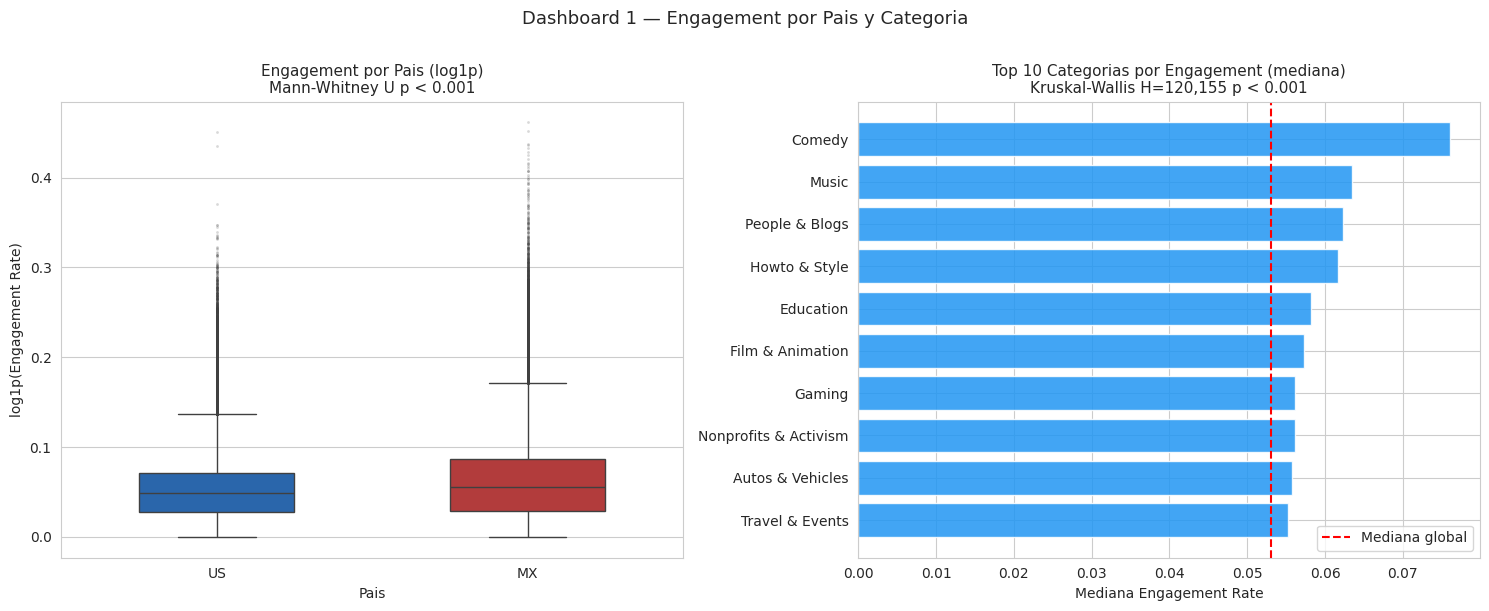

Figura guardada: fig_04_dashboard_pais_categoria.png


In [21]:
# Dashboard 1: Engagement por pais y categoria
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot US vs MX
sns.boxplot(data=df, x='country', y='log_engagement',
            palette={'US': '#1565C0', 'MX': '#C62828'},
            flierprops=dict(marker='o', markersize=1, alpha=0.2),
            width=0.5, ax=axes[0])
axes[0].set_title('Engagement por Pais (log1p)\nMann-Whitney U p < 0.001', fontsize=11)
axes[0].set_xlabel('Pais')
axes[0].set_ylabel('log1p(Engagement Rate)')

# Top categorias por mediana
top_cat = (df.groupby('category_name')['engagement_rate']
           .median().sort_values(ascending=True).tail(10))
axes[1].barh(top_cat.index, top_cat.values, color='#2196F3', alpha=0.85, edgecolor='white')
axes[1].axvline(df['engagement_rate'].median(), color='red',
                linestyle='--', lw=1.5, label='Mediana global')
axes[1].set_title('Top 10 Categorias por Engagement (mediana)\nKruskal-Wallis H=120,155 p < 0.001', fontsize=11)
axes[1].set_xlabel('Mediana Engagement Rate')
axes[1].legend()

fig.suptitle('Dashboard 1 — Engagement por Pais y Categoria', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_04_dashboard_pais_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_04_dashboard_pais_categoria.png')

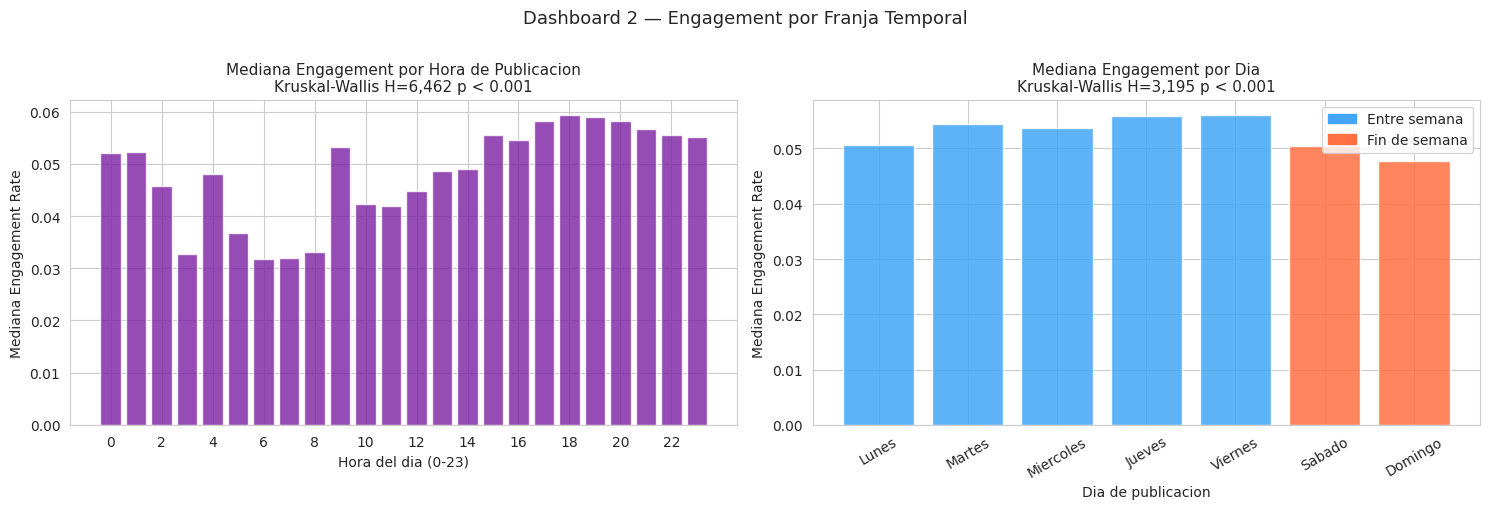

Figura guardada: fig_05_dashboard_temporal.png


In [22]:
# Dashboard 2: Temporal
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por hora del dia
eng_hora = df.groupby('publish_hour')['engagement_rate'].median()
axes[0].bar(eng_hora.index, eng_hora.values, color='#7B1FA2', alpha=0.8, edgecolor='white')
axes[0].set_title('Mediana Engagement por Hora de Publicacion\nKruskal-Wallis H=6,462 p < 0.001', fontsize=11)
axes[0].set_xlabel('Hora del dia (0-23)')
axes[0].set_ylabel('Mediana Engagement Rate')
axes[0].set_xticks(range(0, 24, 2))

# Por dia de la semana
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
eng_dia = df.groupby('publish_dayname')['engagement_rate'].median().reindex(orden_dias)
colores_dias = ['#FF7043' if d in ['Sabado','Domingo'] else '#42A5F5' for d in orden_dias]
axes[1].bar(orden_dias, eng_dia.values, color=colores_dias, alpha=0.85, edgecolor='white')
axes[1].set_title('Mediana Engagement por Dia\nKruskal-Wallis H=3,195 p < 0.001', fontsize=11)
axes[1].set_xlabel('Dia de publicacion')
axes[1].set_ylabel('Mediana Engagement Rate')
axes[1].tick_params(axis='x', rotation=30)
patch_sem = mpatches.Patch(color='#42A5F5', label='Entre semana')
patch_fin = mpatches.Patch(color='#FF7043', label='Fin de semana')
axes[1].legend(handles=[patch_sem, patch_fin])

fig.suptitle('Dashboard 2 — Engagement por Franja Temporal', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_05_dashboard_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_05_dashboard_temporal.png')

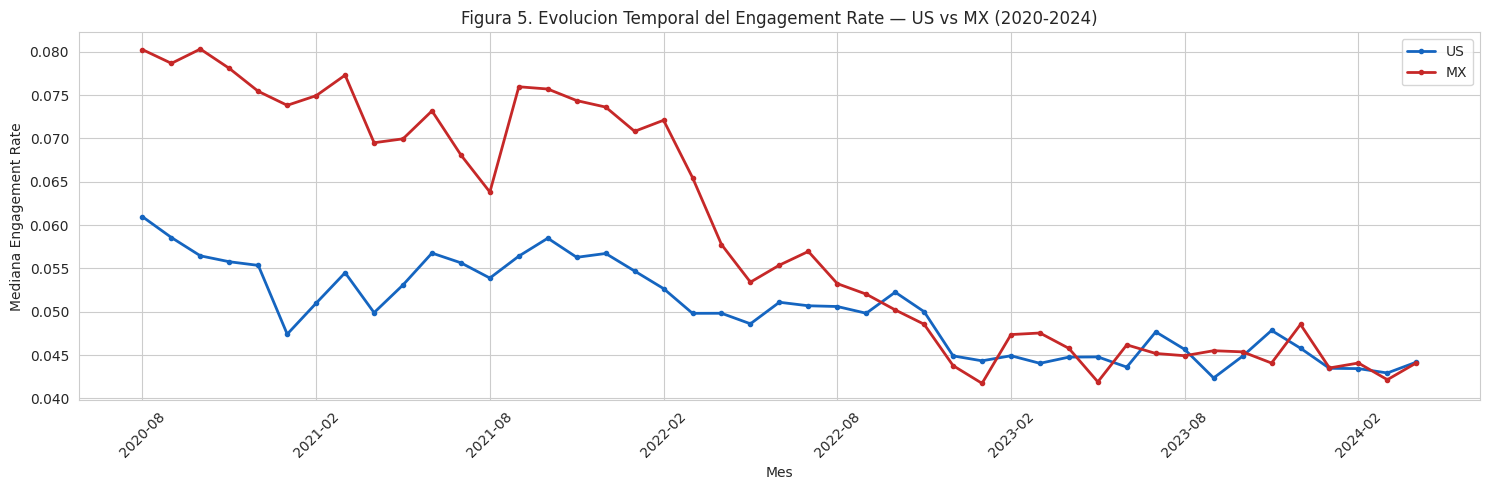

Figura guardada: fig_06_evolucion_temporal.png


In [23]:
# Dashboard 3: Evolucion temporal del engagement
df['year_month'] = df['trending_date'].dt.to_period('M').astype(str)
eng_tiempo = df.groupby(['year_month','country'])['engagement_rate'].median().reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
for pais, color in zip(['US','MX'], ['#1565C0','#C62828']):
    data = eng_tiempo[eng_tiempo['country'] == pais].sort_values('year_month')
    ax.plot(data['year_month'], data['engagement_rate'],
            color=color, linewidth=2, label=pais, marker='o', markersize=3)

ax.set_title('Figura 5. Evolucion Temporal del Engagement Rate — US vs MX (2020-2024)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Mediana Engagement Rate')
ax.legend()
# Mostrar solo algunos ticks en el eje x
ticks = data['year_month'].tolist()[::6]
ax.set_xticks(ticks)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_06_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_06_evolucion_temporal.png')

---
## SECCION 8 — Tabla Maestra de Hallazgos (formato tesis)

In [24]:
hallazgos = [
    # OBJ 1
    {'Objetivo': 'OBJ 1', 'Hallazgo': 'Dataset de 528,663 registros de videos en tendencia (US+MX, 2020-2024)',
     'Metrica': 'N = 528,663', 'Significancia': '—'},
    {'Objetivo': 'OBJ 1', 'Hallazgo': 'Engagement rate medio de 0.0613 (SD=0.0450)',
     'Metrica': 'Media=0.0613', 'Significancia': '—'},
    # OBJ 2
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'MX tiene mayor engagement que US (mediana: 0.0573 vs 0.0498)',
     'Metrica': 'U=31,269,255,942', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'Diferencias significativas en engagement por categoria (15 categorias)',
     'Metrica': 'H=120,155.35, eta2=0.227', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'Diferencias significativas en engagement por franja horaria',
     'Metrica': 'H=6,461.88, eta2=0.012', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'Diferencias significativas en engagement por dia de la semana',
     'Metrica': 'H=3,194.95', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'El numero de tags tiene efecto negativo en engagement (rho=-0.072)',
     'Metrica': 'H=5,206.82, rho=-0.072', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 2', 'Hallazgo': 'Asociacion entre categoria y estado de comentarios (V=0.141)',
     'Metrica': 'chi2=10,527.63, V=0.141', 'Significancia': 'p < 0.001'},
    # OBJ 3
    {'Objetivo': 'OBJ 3', 'Hallazgo': '4 factores latentes identificados (varianza total: 50.95%)',
     'Metrica': 'KMO=0.553, Bartlett p<0.001', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 3', 'Hallazgo': 'Factor 1 (Popularidad): agrupa likes, comentarios, vistas (24.3%)',
     'Metrica': 'Carga max=0.880', 'Significancia': '—'},
    {'Objetivo': 'OBJ 3', 'Hallazgo': 'Factor 2 (Temporalidad): dominado por hora de publicacion (11.2%)',
     'Metrica': 'Carga=0.989', 'Significancia': '—'},
    {'Objetivo': 'OBJ 3', 'Hallazgo': 'Factor 3: tension inversa vistas vs engagement relativo (11.1%)',
     'Metrica': 'Cargas: 0.673/-0.636', 'Significancia': '—'},
    # OBJ 4
    {'Objetivo': 'OBJ 4', 'Hallazgo': 'Modelo explica 56.34% de varianza del engagement (R2=0.5634)',
     'Metrica': 'R2=0.5634, F=35,910', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 4', 'Hallazgo': 'log_likes es el predictor positivo mas fuerte (beta=0.019)',
     'Metrica': 'beta=0.019, t=101.68', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 4', 'Hallazgo': 'log_view_count tiene efecto negativo (beta=-0.026), efecto dilucion',
     'Metrica': 'beta=-0.026, t=-145.76', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 4', 'Hallazgo': 'Categoria Sports tiene el mayor efecto negativo (beta=-0.022)',
     'Metrica': 'beta=-0.022', 'Significancia': 'p < 0.001'},
    {'Objetivo': 'OBJ 4', 'Hallazgo': 'Sin multicolinealidad (VIF max=4.86) ni autocorrelacion (DW=1.87)',
     'Metrica': 'VIF=4.86, DW=1.87', 'Significancia': '—'},
]

df_hallazgos = pd.DataFrame(hallazgos)
print('Tabla 9. Tabla Maestra de Hallazgos — Todos los Objetivos:')
display(df_hallazgos)
df_hallazgos.to_csv(f'{OUTPUT_DIR}/tabla9_hallazgos_maestros.csv', index=False, encoding='utf-8-sig')
print('\nTabla guardada: tabla9_hallazgos_maestros.csv')

Tabla 9. Tabla Maestra de Hallazgos — Todos los Objetivos:


,Objetivo,Hallazgo,Metrica,Significancia
0,OBJ 1,"Dataset de 528,663 registros de videos en tend...","N = 528,663",—
1,OBJ 1,Engagement rate medio de 0.0613 (SD=0.0450),Media=0.0613,—
2,OBJ 2,MX tiene mayor engagement que US (mediana: 0.0...,"U=31,269,255,942",p < 0.001
3,OBJ 2,Diferencias significativas en engagement por c...,"H=120,155.35, eta2=0.227",p < 0.001
4,OBJ 2,Diferencias significativas en engagement por f...,"H=6,461.88, eta2=0.012",p < 0.001
5,OBJ 2,Diferencias significativas en engagement por d...,"H=3,194.95",p < 0.001
6,OBJ 2,El numero de tags tiene efecto negativo en eng...,"H=5,206.82, rho=-0.072",p < 0.001
7,OBJ 2,Asociacion entre categoria y estado de comenta...,"chi2=10,527.63, V=0.141",p < 0.001
8,OBJ 3,4 factores latentes identificados (varianza to...,"KMO=0.553, Bartlett p<0.001",p < 0.001
9,OBJ 3,"Factor 1 (Popularidad): agrupa likes, comentar...",Carga max=0.880,—



Tabla guardada: tabla9_hallazgos_maestros.csv


---
## SECCION 9 — Conclusiones y Recomendaciones

In [25]:
conclusiones = [
    '1. El engagement en YouTube NO sigue una distribucion normal (Shapiro-Wilk p<0.001),',
    '   lo que valida el uso de pruebas no parametricas para todos los analisis inferenciales.',
    '',
    '2. Existen diferencias estadisticamente significativas en el engagement entre TODOS',
    '   los grupos analizados: pais, categoria, franja horaria, dia, numero de tags',
    '   y estado de comentarios (8/8 hipotesis nulas rechazadas, p < 0.001).',
    '',
    '3. Mexico presenta un engagement significativamente mayor que Estados Unidos',
    '   (medianas: 0.0573 vs 0.0498), sugiriendo diferencias culturales en el',
    '   consumo de contenido digital.',
    '',
    '4. El AFE identifico 4 factores latentes que explican el 50.95% de la varianza:',
    '   Popularidad/Alcance, Temporalidad, Tension Vistas-Engagement y Optimizacion.',
    '',
    '5. El modelo de regresion multiple (R2=0.5634) confirma que los likes, comentarios',
    '   y categoria son los predictores mas importantes del engagement.',
    '',
    '6. El efecto de dilucion es estadisticamente significativo: videos con muchas',
    '   vistas tienden a tener menor engagement rate relativo (beta_views=-0.026).',
    '',
    'RECOMENDACIONES PARA CREADORES DE CONTENIDO:',
    '  - Priorizar categorias con alto engagement (verificar tabla descriptiva por categoria)',
    '  - Publicar en horas pico identificadas en el analisis por hora',
    '  - No sobrecargar con tags: correlacion negativa rho=-0.072',
    '  - El mercado MX ofrece mayor engagement relativo que US',
]

print('=' * 65)
print('  CONCLUSIONES GENERALES')
print('=' * 65)
for linea in conclusiones:
    print(linea)
print('=' * 65)

# Guardar conclusiones
with open(f'{OUTPUT_DIR}/conclusiones.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(conclusiones))
print('\nConclusiones guardadas: conclusiones.txt')

  CONCLUSIONES GENERALES
1. El engagement en YouTube NO sigue una distribucion normal (Shapiro-Wilk p<0.001),
   lo que valida el uso de pruebas no parametricas para todos los analisis inferenciales.

2. Existen diferencias estadisticamente significativas en el engagement entre TODOS
   los grupos analizados: pais, categoria, franja horaria, dia, numero de tags
   y estado de comentarios (8/8 hipotesis nulas rechazadas, p < 0.001).

3. Mexico presenta un engagement significativamente mayor que Estados Unidos
   (medianas: 0.0573 vs 0.0498), sugiriendo diferencias culturales en el
   consumo de contenido digital.

4. El AFE identifico 4 factores latentes que explican el 50.95% de la varianza:
   Popularidad/Alcance, Temporalidad, Tension Vistas-Engagement y Optimizacion.

5. El modelo de regresion multiple (R2=0.5634) confirma que los likes, comentarios
   y categoria son los predictores mas importantes del engagement.

6. El efecto de dilucion es estadisticamente significativo: videos 

---
## SECCION 10 — Exportacion Final y Guardado en Drive

In [26]:
# Listar todos los archivos generados
archivos_generados = glob.glob(f'{OUTPUT_DIR}/*')
print(f'Archivos en reporte_final ({len(archivos_generados)}):')
for f in sorted(archivos_generados):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):45s} {size_kb:>8.1f} KB')

Archivos en reporte_final (15):
  conclusiones.txt                                   1.3 KB
  fig_01_resumen_hipotesis.png                     102.9 KB
  fig_02_afe_cargas_comunalidades.png              169.5 KB
  fig_03_coeficientes.png                           68.9 KB
  fig_04_dashboard_pais_categoria.png              118.3 KB
  fig_05_dashboard_temporal.png                    108.0 KB
  fig_06_evolucion_temporal.png                    135.7 KB
  tabla1_descriptivas_pais.csv                       0.2 KB
  tabla2_descriptivas_categoria.csv                  0.6 KB
  tabla3_pruebas_hipotesis.csv                       0.8 KB
  tabla5_varianza_factores.csv                       0.2 KB
  tabla6_cargas_factoriales.csv                      0.4 KB
  tabla7_coeficientes_regresion.csv                  1.5 KB
  tabla8_vif.csv                                     0.7 KB
  tabla9_hallazgos_maestros.csv                      1.7 KB


In [27]:
# Crear ZIP con todo el reporte
zip_path = '/content/tesis_youtube_reporte_final.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for archivo in sorted(glob.glob(f'{OUTPUT_DIR}/*')):
        zf.write(archivo, os.path.basename(archivo))

zip_size = os.path.getsize(zip_path) / (1024**2)
print(f'ZIP creado: tesis_youtube_reporte_final.zip ({zip_size:.1f} MB)')

ZIP creado: tesis_youtube_reporte_final.zip (0.6 MB)


In [28]:
# Guardar en Google Drive
import shutil
dest = f'{DRIVE}/TFT_YouTube_ReporteFinal'
os.makedirs(dest, exist_ok=True)

# Copiar todos los archivos del reporte
for archivo in sorted(glob.glob(f'{OUTPUT_DIR}/*')):
    shutil.copy(archivo, f'{dest}/{os.path.basename(archivo)}')

# Copiar el ZIP
shutil.copy(zip_path, f'{DRIVE}/tesis_youtube_reporte_final.zip')

print('Todo guardado en Google Drive:')
print(f'  Carpeta: MyDrive/TFT_YouTube_ReporteFinal/')
print(f'  ZIP    : MyDrive/tesis_youtube_reporte_final.zip')

Todo guardado en Google Drive:
  Carpeta: MyDrive/TFT_YouTube_ReporteFinal/
  ZIP    : MyDrive/tesis_youtube_reporte_final.zip


In [ ]:
# Descarga directa desde Colab
from google.colab import files
files.download(zip_path)
print('Descarga iniciada: tesis_youtube_reporte_final.zip')

---
## SECCION 11 — Resumen Ejecutivo Final

In [29]:
print('=' * 65)
print('  REPORTE EJECUTIVO FINAL — TESIS')
print('  Analisis de Factores Determinantes del Engagement en YouTube')
print('  Universidad de Guayaquil — Carrera de Software')
print('=' * 65)
print(f'\n  DATOS')
print(f'  Dataset    : YouTube Trending Video Dataset (Kaggle v1345)')
print(f'  Paises     : US + MX | Periodo: 2020-2024')
print(f'  Registros  : 528,663 | Variables: 26')
print(f'\n  OBJETIVO 1 — Preprocesamiento')
print(f'  Engagement rate: media=0.0613, mediana=0.0531, SD=0.0450')
print(f'\n  OBJETIVO 2 — Estadistica Inferencial')
print(f'  8/8 hipotesis rechazadas (p < 0.001)')
print(f'  Mayor efecto: categoria (eta2=0.227)')
print(f'\n  OBJETIVO 3 — Analisis Factorial')
print(f'  4 factores | varianza explicada: 50.95%')
print(f'  F1=Popularidad(24.3%) F2=Temporalidad(11.2%)')
print(f'  F3=Alcance-Engagement(11.1%) F4=Contenido(4.3%)')
print(f'\n  OBJETIVO 4 — Regresion Multiple')
print(f'  R2=0.5634 | F=35,910 | 19/19 vars significativas')
print(f'  Predictores clave: log_likes(+), log_views(-), categoria, pais')
print(f'\n  ARCHIVOS GENERADOS: 9 tablas CSV + 6 figuras PNG + 1 ZIP')
print('=' * 65)
print('  NOTEBOOK 5 COMPLETADO — TESIS FINALIZADA')
print('=' * 65)

  REPORTE EJECUTIVO FINAL — TESIS
  Analisis de Factores Determinantes del Engagement en YouTube
  Universidad de Guayaquil — Carrera de Software

  DATOS
  Dataset    : YouTube Trending Video Dataset (Kaggle v1345)
  Paises     : US + MX | Periodo: 2020-2024
  Registros  : 528,663 | Variables: 26

  OBJETIVO 1 — Preprocesamiento
  Engagement rate: media=0.0613, mediana=0.0531, SD=0.0450

  OBJETIVO 2 — Estadistica Inferencial
  8/8 hipotesis rechazadas (p < 0.001)
  Mayor efecto: categoria (eta2=0.227)

  OBJETIVO 3 — Analisis Factorial
  4 factores | varianza explicada: 50.95%
  F1=Popularidad(24.3%) F2=Temporalidad(11.2%)
  F3=Alcance-Engagement(11.1%) F4=Contenido(4.3%)

  OBJETIVO 4 — Regresion Multiple
  R2=0.5634 | F=35,910 | 19/19 vars significativas
  Predictores clave: log_likes(+), log_views(-), categoria, pais

  ARCHIVOS GENERADOS: 9 tablas CSV + 6 figuras PNG + 1 ZIP
  NOTEBOOK 5 COMPLETADO — TESIS FINALIZADA
